# Tarea 2: Regresión logística

**Instituto Tecnológico de Costa Rica**  
**Curso:** Inteligencia Artificial

**Estudiantes:**

| Nombre | Carné |
|---|---|
| Sebastián Chacón Muñoz | 2023221908 |
| Daniel Pulido Castagno | |
| Sebastián Muñoz | |

## Objetivo

Implementar **regresión logística** con **PyTorch** para resolver un problema de clasificación binaria: determinar si un **vino** es **BUENO** o **MALO** a partir de sus características fisicoquímicas.

Se incluye un análisis exploratorio detallado de las características del conjunto de datos y una división de los datos mediante *stratified sampling*.

## Entorno y dependencias

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("PyTorch version: ", torch.__version__)

PyTorch version:  2.14.1+cu130


In [3]:
# Usar GPU (CUDA) si está disponible; si no, usar CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA disponible:", torch.cuda.is_available())
print("Usando:", device, f"({torch.cuda.get_device_name(0)})" if device.type == "cuda" else "")

CUDA disponible: True
Usando: cuda (NVIDIA GeForce RTX 4060)


## Descarga y carga del dataset

Dataset: [Red Wine Quality (Cortez et al., 2009)](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) — Kaggle / UCI.

El archivo `winequality-red.csv` se encuentra en la carpeta `data/` del repositorio.

In [4]:
df = pd.read_csv("data/winequality-red.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.info()
print("\nValores nulos por columna:\n", df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Valores nulos por columna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlo

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## Análisis exploratorio de datos (EDA)

### Feature engineering de la variable objetivo

El *feature engineering* (ingeniería de características) consiste en crear, transformar o combinar variables del conjunto de datos para que el modelo pueda aprender mejor de ellas. Aplicado a la **variable objetivo**, significa adaptarla al tipo de problema que se quiere resolver.

En este caso, la variable `quality` es una calificación entera (0–10), pero la regresión logística es un clasificador **binario**. Por eso se transforma en una variable binaria:

$$\text{target} = \begin{cases} 1 \; (\text{BUENO}) & \text{si } quality \geq 7 \\ 0 \; (\text{MALO}) & \text{en otro caso} \end{cases}$$

#### Justificación del umbral

**1. Criterio estadístico.** Con la media y la desviación estándar de `quality` obtenidas en `df.describe()`:

$$\mu = 5.636, \qquad \sigma = 0.808, \qquad \mu + \sigma = 6.444$$

Como `quality` solo toma valores enteros, el umbral $quality \geq 7$ equivale a $quality > \mu + \sigma$: un vino se considera **BUENO** cuando su calificación está más de una desviación estándar por encima de la media, es decir, cuando es claramente superior al vino típico del conjunto.

**2. Distribución de los datos.** Las calificaciones 5 y 6 concentran $\frac{681 + 638}{1599} \approx 82.5\%$ de los vinos y corresponden a calidad promedio. Con umbral 6, un vino promedio (calificación 6) quedaría etiquetado como BUENO; con umbral 7 la clase BUENO representa solo calidad realmente alta ($\frac{199 + 18}{1599} \approx 13.6\%$).

**3. Convención en la literatura.** La descripción del dataset en Kaggle propone este mismo corte ("7 or higher" → *good*), y es el criterio usado habitualmente en trabajos de clasificación sobre este dataset. Los autores originales (Cortez et al., 2009) tratan `quality` como una puntuación sensorial y señalan que las clases están desbalanceadas (hay muchos más vinos normales que excelentes o malos), por lo que la binarización es una decisión de modelado.

**Consecuencia:** el target queda desbalanceado (~14% BUENO vs. ~86% MALO). Por ello se usa *stratified sampling* en la división de datos y se priorizan F1-score y AUC sobre el accuracy, ya que un modelo que siempre prediga MALO obtendría ~86% de accuracy sin aprender nada.

**Referencias**
- P. Cortez, A. Cerdeira, F. Almeida, T. Matos y J. Reis, "Modeling wine preferences by data mining from physicochemical properties", *Decision Support Systems*, vol. 47, no. 4, pp. 547–553, 2009.
- UCI Machine Learning Repository, *Wine Quality*: https://archive.ics.uci.edu/dataset/186/wine+quality
- Kaggle, *Red Wine Quality (Cortez et al., 2009)*: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

In [7]:
mu, sigma = df["quality"].mean(), df["quality"].std()
print(f"mu = {mu:.3f}, sigma = {sigma:.3f}, mu + sigma = {mu + sigma:.3f}")

UMBRAL = 7  # quality >= 7  <=>  quality > mu + sigma (valores enteros)
df["target"] = (df["quality"] >= UMBRAL).astype(int)

print(df["quality"].value_counts().sort_index())
print("\nDistribución del target:\n", df["target"].value_counts(normalize=True))

mu = 5.636, sigma = 0.808, mu + sigma = 6.444
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Distribución del target:
 target
0    0.86429
1    0.13571
Name: proportion, dtype: float64


### Histogramas

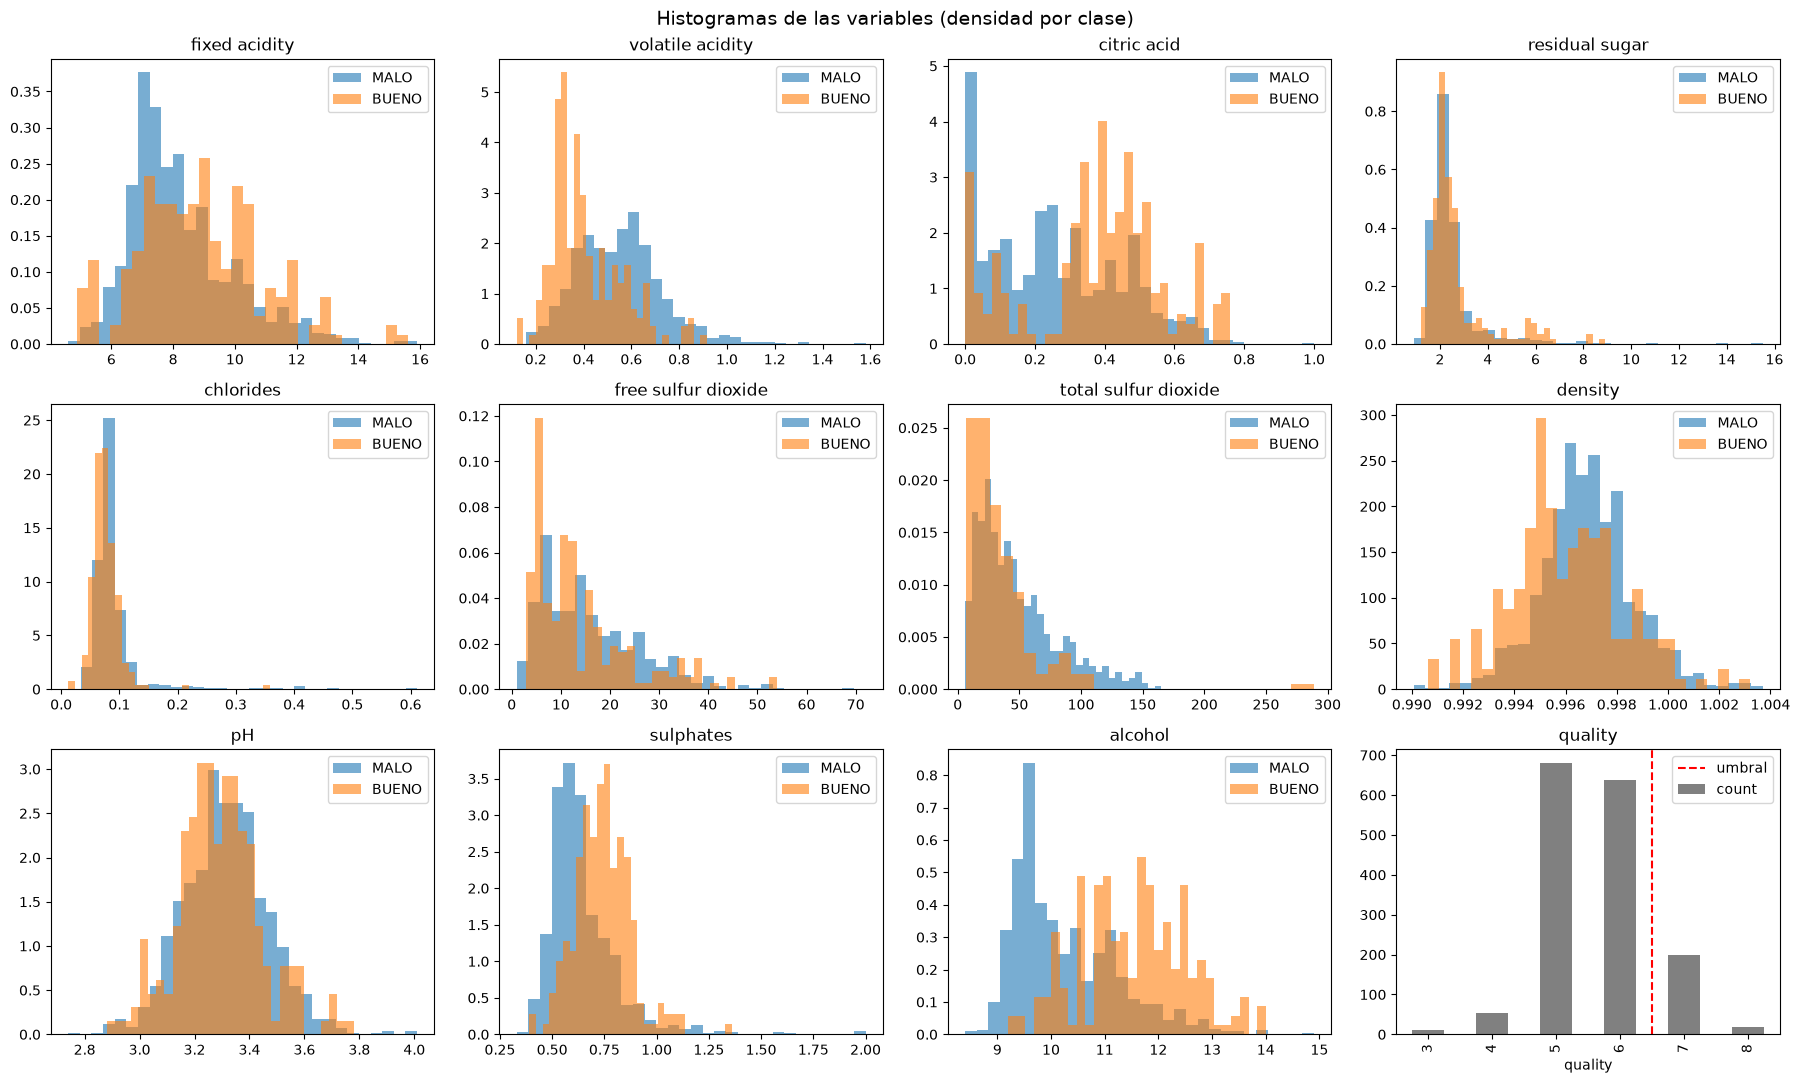

,skewness
chlorides,5.680347
residual sugar,4.540655
sulphates,2.428672
total sulfur dioxide,1.515531
free sulfur dioxide,1.250567
fixed acidity,0.982751
alcohol,0.860829
volatile acidity,0.671593
citric acid,0.318337
pH,0.193683


In [8]:
features = [c for c in df.columns if c not in ("quality", "target")]

# Histograma de cada feature, separando las clases MALO / BUENO
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, features):
    ax.hist(df.loc[df["target"] == 0, col], bins=30, alpha=0.6, density=True, label="MALO")
    ax.hist(df.loc[df["target"] == 1, col], bins=30, alpha=0.6, density=True, label="BUENO")
    ax.set_title(col)
    ax.legend()

# Último panel: distribución de quality (variable original)
ax = axes.flat[len(features)]
df["quality"].value_counts().sort_index().plot.bar(ax=ax, color="gray")
ax.axvline(x=list(sorted(df["quality"].unique())).index(UMBRAL) - 0.5, color="red", ls="--", label="umbral")
ax.set_title("quality")
ax.legend()

fig.suptitle("Histogramas de las variables (densidad por clase)", fontsize=14)
plt.tight_layout()
plt.show()

# Asimetría de cada variable (|skew| > 1 indica distribución muy sesgada)
df[features].skew().sort_values(ascending=False).to_frame("skewness")

**Observaciones:**

Al comparar las dos clases, la variable que más se diferencia es `alcohol`: los vinos buenos suelen tener más alcohol que los malos. También se nota diferencia en `volatile acidity` (los buenos tienen menos), en `sulphates` (los buenos tienen un poco más) y en `citric acid` (muchos vinos malos tienen casi cero). En cambio, en `residual sugar`, `chlorides`, `free sulfur dioxide` y `pH` las dos clases se ven casi iguales, así que probablemente no ayuden mucho al modelo.

Varias variables, como `chlorides`, `residual sugar` y `sulphates`, tienen la mayoría de los datos en valores bajos y unos pocos valores muy altos, lo que indica posibles outliers. Además, las variables tienen escalas muy distintas, por lo que hay que estandarizarlas antes de entrenar. Por último, el gráfico de `quality` confirma que la mayoría de los vinos tienen nota 5 o 6, y que hay muchos menos vinos buenos que malos.

### Boxplots de variables numéricas

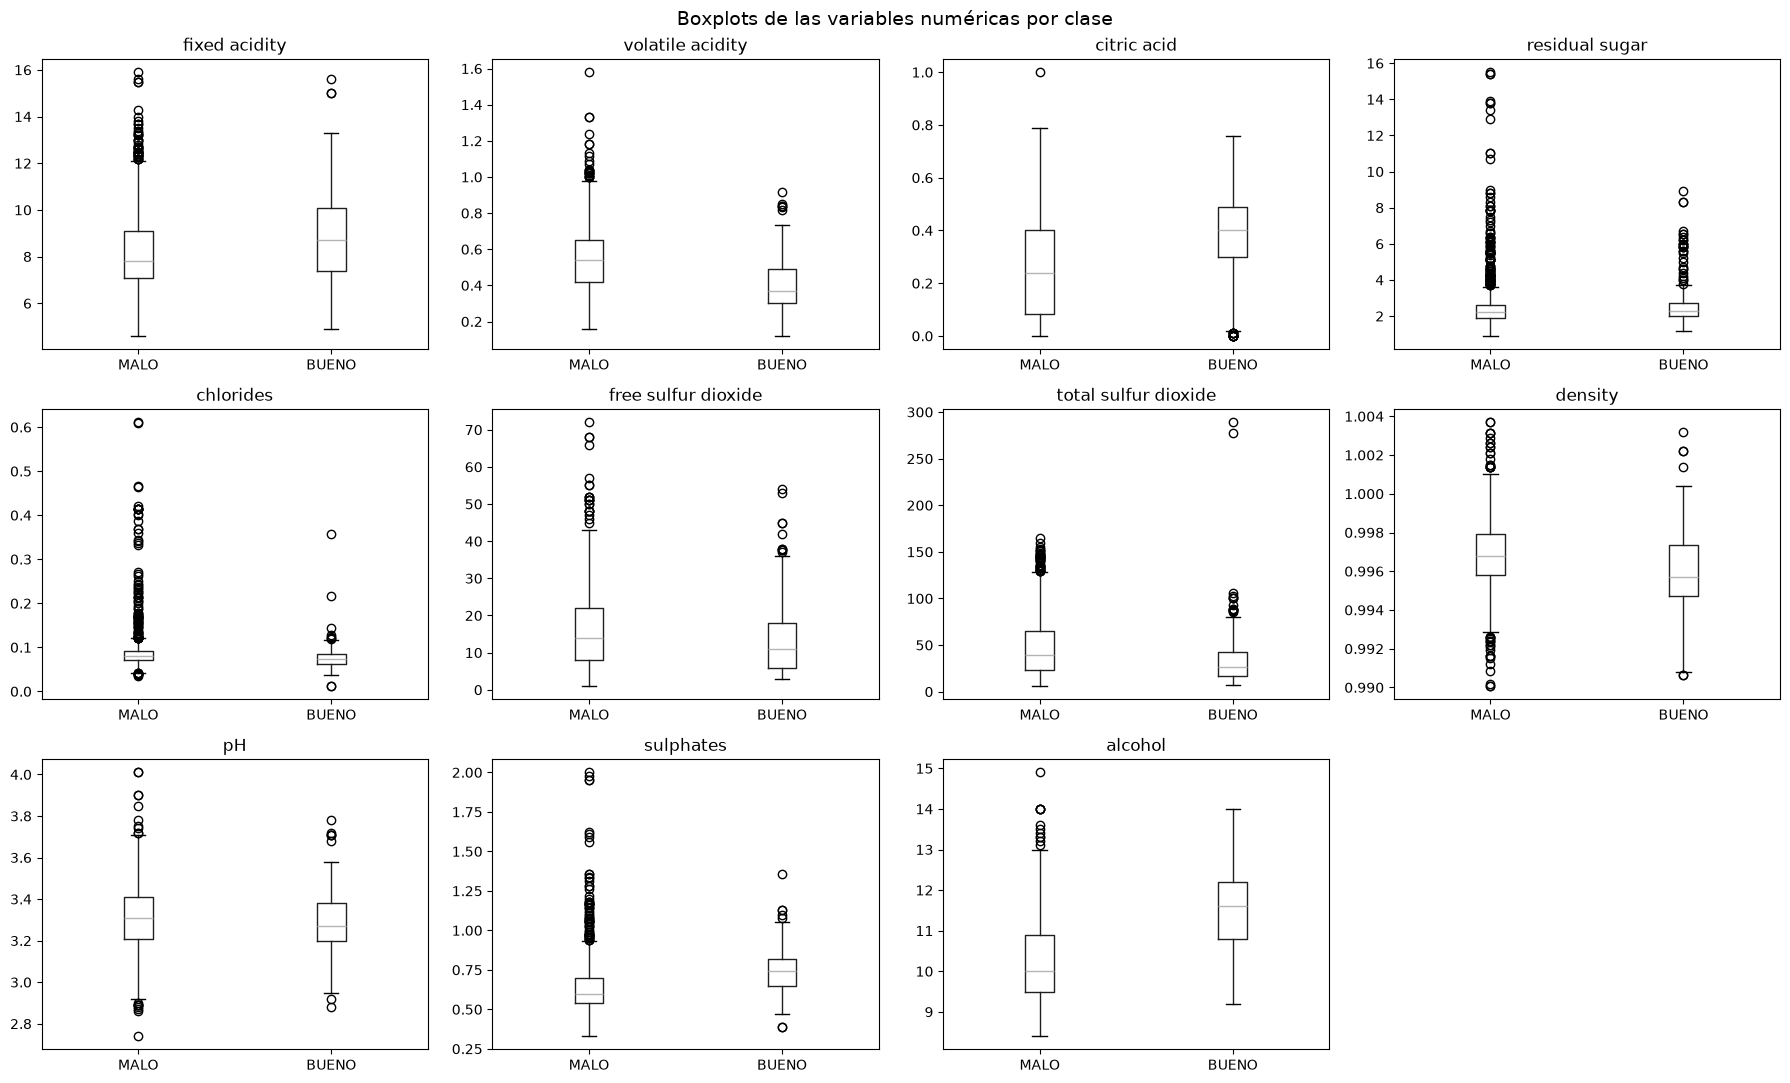

,outliers (IQR)
residual sugar,155
chlorides,112
sulphates,59
total sulfur dioxide,55
fixed acidity,49
density,45
pH,35
free sulfur dioxide,30
volatile acidity,19
alcohol,13


In [9]:
# Boxplot de cada feature separado por clase
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, features):
    df.boxplot(column=col, by="target", ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_xticks([1, 2], ["MALO", "BUENO"])
axes.flat[-1].set_visible(False)

fig.suptitle("Boxplots de las variables numéricas por clase", fontsize=14)
plt.tight_layout()
plt.show()

# Cantidad de outliers por variable según el criterio IQR (fuera de [Q1 - 1.5 IQR, Q3 + 1.5 IQR])
q1, q3 = df[features].quantile(0.25), df[features].quantile(0.75)
iqr = q3 - q1
outliers = ((df[features] < q1 - 1.5 * iqr) | (df[features] > q3 + 1.5 * iqr)).sum()
outliers.sort_values(ascending=False).to_frame("outliers (IQR)")

**Observaciones (outliers, diferencias entre clases):**

Los boxplots confirman lo que se vio en los histogramas. La mediana de `alcohol` es claramente más alta en los vinos buenos, la de `volatile acidity` es más baja, y en `sulphates` y `citric acid` los buenos también quedan un poco por encima. En variables como `residual sugar`, `chlorides`, `free sulfur dioxide` y `pH` las cajas de ambas clases están casi a la misma altura, así que no parecen diferenciar bien.

Hay bastantes outliers, sobre todo en `residual sugar` (155) y `chlorides` (112), seguidos de `sulphates` y `total sulfur dioxide`. Por otro lado, `alcohol` y `citric acid` casi no tienen. Parecen valores posibles en un vino y no errores de medición, así que se decidió no eliminarlos.

### Diagramas de dispersión (características vs. target)

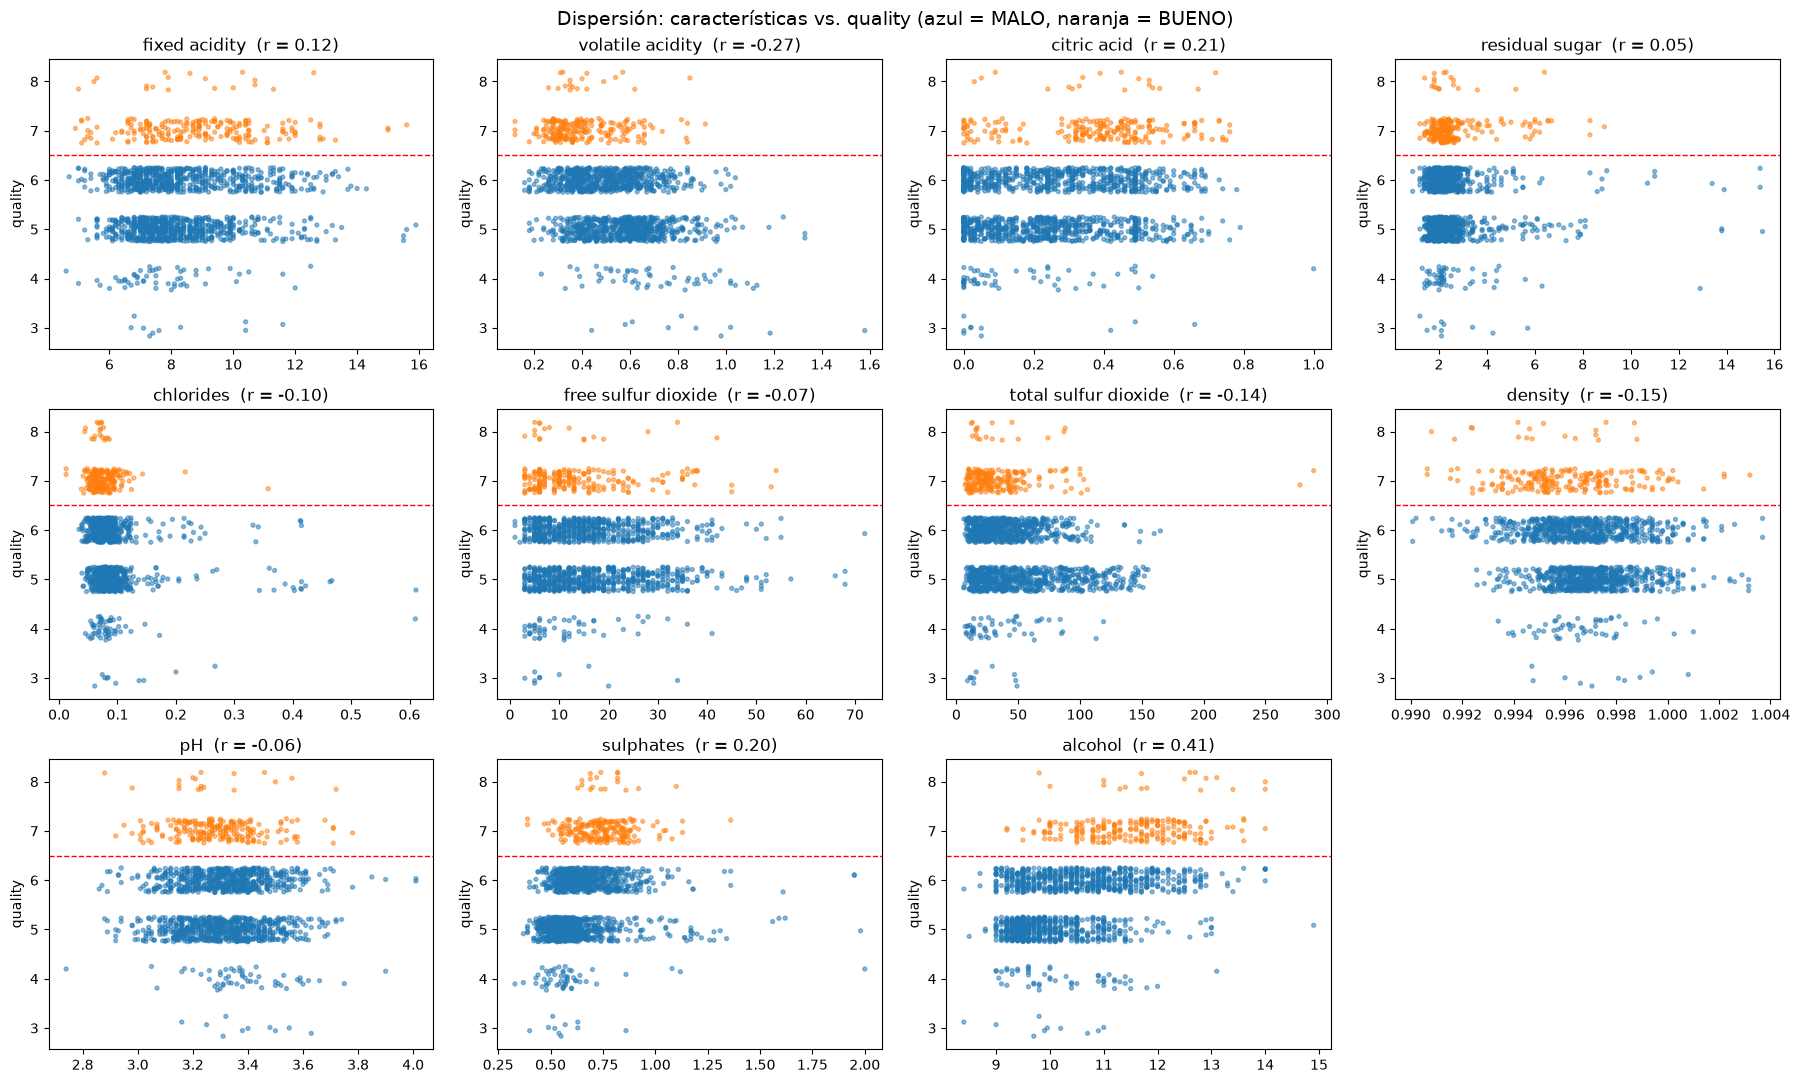

In [10]:
# Dispersión de cada feature contra quality, coloreado por target.
# Se agrega un pequeño "jitter" vertical porque quality es entera y los puntos se superpondrían.
rng = np.random.default_rng(SEED)
jitter = df["quality"] + rng.uniform(-0.25, 0.25, len(df))
colors = df["target"].map({0: "tab:blue", 1: "tab:orange"})

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, features):
    ax.scatter(df[col], jitter, c=colors, s=8, alpha=0.5)
    ax.axhline(UMBRAL - 0.5, color="red", ls="--", lw=1)
    ax.set_title(f"{col}  (r = {df[col].corr(df['target']):.2f})")
    ax.set_ylabel("quality")
axes.flat[-1].set_visible(False)

fig.suptitle("Dispersión: características vs. quality (azul = MALO, naranja = BUENO)", fontsize=14)
plt.tight_layout()
plt.show()

**Observaciones:**

En los diagramas se ve que los puntos naranjas (vinos buenos) quedan arriba de la línea roja y los azules abajo, pero en casi todas las variables los dos colores se mezclan a lo largo del eje horizontal. La excepción más clara es `alcohol` (r = 0.41): a medida que aumenta el alcohol hay más puntos naranjas. También se nota una tendencia en `volatile acidity` (r = -0.27), donde los vinos buenos se concentran en valores bajos, y algo más débil en `citric acid` (0.21) y `sulphates` (0.20).

En el resto de variables los puntos se ven repartidos igual en todas las calidades y la correlación está cerca de 0, por ejemplo en `residual sugar` (0.05) y `pH` (-0.06). Como ninguna variable separa las clases por sí sola, el modelo va a necesitar combinar varias.

### Matriz de correlación (heatmap)

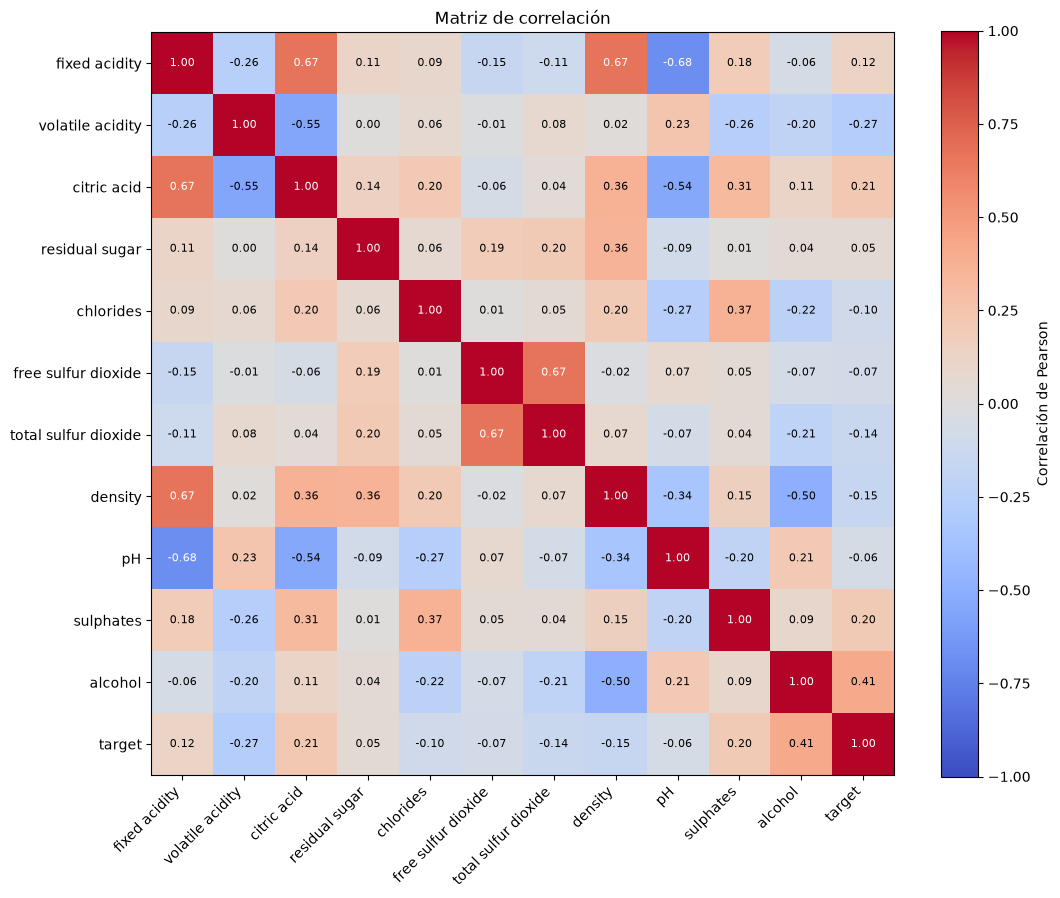

,corr con target
alcohol,0.407315
volatile acidity,-0.270712
citric acid,0.214716
sulphates,0.199485
density,-0.150460
total sulfur dioxide,-0.139517
fixed acidity,0.120061
chlorides,-0.097308
free sulfur dioxide,-0.071747
pH,-0.057283


In [11]:
corr = df.drop(columns=["quality"]).corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="Correlación de Pearson")
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Correlación de cada feature con el target, ordenada por magnitud
corr["target"].drop("target").sort_values(key=abs, ascending=False).to_frame("corr con target")

**Observaciones (correlación con el target, multicolinealidad):**

Con respecto al target, la variable con mayor correlación es `alcohol` (0.41), seguida de `volatile acidity` (-0.27), `citric acid` (0.21) y `sulphates` (0.20). Las demás tienen correlaciones bajas, cerca de 0, como `residual sugar` (0.05) o `pH` (-0.06). Esto coincide con lo que se vio en los gráficos anteriores.

Entre las variables también hay algunas correlaciones fuertes. `fixed acidity` está relacionada con `citric acid` (0.67), `density` (0.67) y `pH` (-0.68), y `free sulfur dioxide` con `total sulfur dioxide` (0.67). También `density` y `alcohol` tienen una correlación de -0.50. Estas variables repiten en parte la misma información, así que no conviene incluir varias de un mismo grupo en el modelo. Por ejemplo, si se usa `alcohol` probablemente no haga falta `density`.

### Selección de características (máximo 6)

Se seleccionan como máximo 6 features y se descartan las sobrantes.

**Justificación matemática:** se combinaron tres criterios. Los dos primeros miden qué tanto se relaciona cada variable con el target y el tercero mide qué tanto se repiten las variables entre sí.

**1. Correlación punto-biserial con el target.** Como el target es binario, la correlación de Pearson entre una variable $x$ y el target equivale a la correlación punto-biserial:

$$r_{pb} = \frac{\bar{x}_1 - \bar{x}_0}{s_x}\sqrt{p(1-p)}$$

donde $\bar{x}_1$ y $\bar{x}_0$ son las medias de la variable en vinos BUENOS y MALOS, $s_x$ es la desviación estándar y $p$ es la proporción de vinos BUENOS. Es decir, mide qué tan separadas están las medias de las dos clases, que es justo lo que se observó en los histogramas y boxplots.

**2. Información mutua (MI).** La correlación solo detecta relaciones lineales. La información mutua mide cualquier tipo de dependencia entre la variable y el target (vale 0 si son independientes):

$$I(X;Y) = \sum_{y}\int p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}\,dx$$

**3. Factor de inflación de la varianza (VIF).** Mide la multicolinealidad: qué tanto se puede explicar una variable con las demás.

$$VIF_j = \frac{1}{1 - R_j^2}$$

donde $R_j^2$ es el coeficiente de determinación al predecir $x_j$ con el resto de variables. Un $VIF$ cercano a 1 indica que la variable aporta información propia. Valores mayores a 5 indican que es redundante y vuelven inestables los pesos de la regresión logística.

**Resultados y decisión:**

- `alcohol`, `volatile acidity`, `citric acid` y `sulphates` son las 4 mejores tanto en $|r|$ como en MI, así que se escogen directamente.
- `density` y `fixed acidity` siguen en el ranking, pero son las que tienen mayor VIF (6.34 y 7.77). `density` depende mucho de `alcohol` ($r = -0.50$) y `fixed acidity` de `citric acid` y `pH` ($|r| \approx 0.67$). Repiten información que ya está en el modelo, así que se descartan.
- Entre los dos dióxidos de azufre ($r = 0.67$ entre ellos) se queda `total sulfur dioxide`, porque tiene mayor correlación con el target (−0.14 frente a −0.07).
- La sexta es `chlorides` ($r = -0.10$, MI = 0.029), que sigue en el ranking y casi no está correlacionada con las otras.
- `residual sugar`, `pH` y `free sulfur dioxide` se descartan por tener correlación y MI cercanas a 0.

Con las 6 seleccionadas, el VIF máximo baja de 7.77 a aproximadamente 1.6, y una regresión logística de prueba (validación cruzada de 5 particiones) obtiene prácticamente el mismo AUC que usando las 11 variables (≈ 0.88). O sea, se eliminan 5 variables sin perder capacidad de predicción.

In [12]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.model_selection import cross_val_score

X_all, y_all = df[features], df["target"]

def vif(cols):
    # VIF_j = 1 / (1 - R_j^2) = elemento j de la diagonal de la inversa de la matriz de correlación
    return pd.Series(np.diag(np.linalg.inv(X_all[cols].corr().values)), index=cols)

ranking = pd.DataFrame({
    "r (punto-biserial)": X_all.corrwith(y_all),
    "MI": mutual_info_classif(X_all, y_all, random_state=SEED),
    "VIF (11 features)": vif(features),
}).sort_values("MI", ascending=False)
display(ranking.round(3))

selected_features = ["alcohol", "volatile acidity", "citric acid",
                     "sulphates", "total sulfur dioxide", "chlorides"]  # máximo 6
print("Features seleccionadas:", selected_features)
print("\nVIF de las seleccionadas:\n", vif(selected_features).round(2))

# Verificación: AUC con validación cruzada usando las 11 features vs. las 6 seleccionadas
X_std = (X_all - X_all.mean()) / X_all.std()
for name, cols in [("11 features", features), ("6 seleccionadas", selected_features)]:
    auc = cross_val_score(SkLogReg(max_iter=1000), X_std[cols], y_all, cv=5, scoring="roc_auc").mean()
    print(f"AUC ({name}): {auc:.3f}")

,r (punto-biserial),MI,VIF (11 features)
alcohol,0.407,0.095,3.031
sulphates,0.199,0.064,1.429
citric acid,0.215,0.064,3.128
volatile acidity,-0.271,0.059,1.789
fixed acidity,0.120,0.048,7.768
density,-0.150,0.039,6.344
chlorides,-0.097,0.029,1.482
total sulfur dioxide,-0.140,0.022,2.187
pH,-0.057,0.016,3.330
free sulfur dioxide,-0.072,0.015,1.963


Features seleccionadas: ['alcohol', 'volatile acidity', 'citric acid', 'sulphates', 'total sulfur dioxide', 'chlorides']

VIF de las seleccionadas:
 alcohol                 1.17
volatile acidity        1.60
citric acid             1.60
sulphates               1.33
total sulfur dioxide    1.06
chlorides               1.35
dtype: float64
AUC (11 features): 0.879
AUC (6 seleccionadas): 0.878


### División en entrenamiento, validación y prueba

**Técnica: Stratified sampling** **70 / 15 / 15.**

Los datos se dividen en dos pasos: primero 70% entrenamiento y 30% temporal, y luego el temporal se parte a la mitad en validación y prueba. En ambos pasos se usa `stratify`, de modo que cada subconjunto conserva la proporción de clases del dataset completo:

$$p_{train} \approx p_{val} \approx p_{test} \approx p = \frac{217}{1599} \approx 0.136$$

Como el target está desbalanceado, con un muestreo aleatorio simple la cantidad de vinos BUENOS en un subconjunto de tamaño $n$ varía con desviación estándar $\sqrt{n\,p(1-p)}$. Para $n = 240$ eso es $\sqrt{240 \cdot 0.136 \cdot 0.864} \approx 5.3$ vinos, es decir, la proporción de BUENOS en validación o prueba podría oscilar aproximadamente entre 9% y 18%, y las métricas (precision, recall, F1) dependerían del azar. La estratificación elimina esa variación y fija ≈ 33 vinos BUENOS en cada subconjunto.

In [13]:
X = df[selected_features].values
y = df["target"].values

# Paso 1: 70% entrenamiento, 30% temporal (estratificado)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
# Paso 2: el 30% temporal se divide a la mitad -> 15% validación, 15% prueba (estratificado)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# Estandarizar usando solo estadísticas del set de entrenamiento (evita data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Verificar que los tres subconjuntos conservan la proporción de clases
print(f"Total: {len(y)} muestras, % BUENO = {y.mean():.3f}")
for name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name}: {len(labels)} muestras ({len(labels) / len(y):.0%}), "
          f"BUENOS = {labels.sum()}, % BUENO = {labels.mean():.3f}")

Total: 1599 muestras, % BUENO = 0.136
Train: 1119 muestras (70%), BUENOS = 152, % BUENO = 0.136
Val: 240 muestras (15%), BUENOS = 33, % BUENO = 0.138
Test: 240 muestras (15%), BUENOS = 32, % BUENO = 0.133


In [14]:
# Convertir a tensores y mover a la GPU
def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32, device=device),
            torch.tensor(y, dtype=torch.float32, device=device).unsqueeze(1))

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t, y_val_t = to_tensors(X_val, y_val)
X_test_t, y_test_t = to_tensors(X_test, y_test)

### Interpretación de resultados del EDA

El dataset tiene 1599 vinos sin valores nulos. Al convertir la calidad en una variable binaria (BUENO si quality ≥ 7), el target queda desbalanceado: solo el 13.6% de los vinos son buenos. Por eso se usó una división estratificada y en la evaluación se le dará más peso a F1 y AUC que al accuracy.

En todos los análisis aparecen las mismas variables como las más relacionadas con la calidad. La más importante es el alcohol (r = 0.41): los vinos buenos tienen más alcohol. Le siguen la acidez volátil (r = -0.27), que es menor en los vinos buenos, y el ácido cítrico y los sulfatos (r ≈ 0.20), que son algo mayores. Variables como el azúcar residual, el pH y el dióxido de azufre libre casi no muestran diferencias entre clases.

También se encontró que algunas variables repiten información. La acidez fija está muy relacionada con el ácido cítrico, la densidad y el pH, y la densidad con el alcohol. Por eso, en la selección de características se dejaron fuera las variables redundantes y se eligieron seis: alcohol, volatile acidity, citric acid, sulphates, total sulfur dioxide y chlorides. Con ellas se logra prácticamente el mismo AUC que con las 11 variables (≈ 0.88).

Varias variables tienen distribuciones sesgadas con outliers (sobre todo residual sugar y chlorides) y escalas muy diferentes entre sí, por lo que se estandarizaron usando solo los datos de entrenamiento. Finalmente, como ninguna variable separa las clases por sí sola y las distribuciones de ambas clases se superponen bastante, se espera que la regresión logística logre un desempeño razonable pero no perfecto, sobre todo al detectar la clase minoritaria.

## Implementación de la regresión logística

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

Un vino se clasifica como BUENO si $\hat{y} \geq 0.5$. Se usa la entropía cruzada binaria (BCE) como pérdida y descenso de gradiente estocástico (SGD) con mini-batches como optimizador.

### Definición del modelo

Una capa `nn.Linear` (pesos $\mathbf{w}$ y sesgo $b$) seguida de la sigmoide.

In [15]:
# Creación de clase Regresión Logística usando PyTorch
class LogisticRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

In [ ]:
# Ejemplo: instancia del modelo con las 6 features seleccionadas
n_features = X_train_t.shape[1]
example_model = LogisticRegression(n_features).to(device)
print(example_model)
print("Parámetros entrenables:", sum(p.numel() for p in example_model.parameters() if p.requires_grad))

LogisticRegression(
  (linear): Linear(in_features=6, out_features=1, bias=True)
)
Parámetros entrenables: 7


### Loop de entrenamiento y validación

Estructura `train_loop` actualiza los pesos en cada mini-batch y `val_loop` calcula la pérdida de validación sin gradientes.

In [17]:
def train_loop(dataloader, model, loss_fn, optimizer):
    # Una época de entrenamiento: recorre todos los mini-batches y actualiza los pesos
    model.train()
    total_loss = 0.0
    for X, y in dataloader:
        # Forward: predicción y cálculo de la pérdida
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation y actualización de los pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X)
    return total_loss / len(dataloader.dataset)


def val_loop(dataloader, model, loss_fn):
    # Pérdida promedio en validación, sin actualizar los pesos
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in dataloader:
            total_loss += loss_fn(model(X), y).item() * len(X)
    return total_loss / len(dataloader.dataset)

### Función de entrenamiento

Se fija la semilla al inicio para que todos los entrenamientos partan de los mismos pesos y el mismo orden de datos.

In [19]:
def train_model(lr, batch_size, epochs, verbose=True):
    # Entrena un modelo y devuelve (modelo, historial de pérdidas por época)
    torch.manual_seed(SEED)

    model = LogisticRegression(X_train_t.shape[1]).to(device)
    loss_fn = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size)

    history = {"train_loss": [], "val_loss": []}
    print_every = max(1, epochs // 10)  # imprimir ~10 líneas por entrenamiento
    for epoch in range(1, epochs + 1):
        train_loss = train_loop(train_loader, model, loss_fn, optimizer)
        val_loss = val_loop(val_loader, model, loss_fn)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose and (epoch == 1 or epoch % print_every == 0):
            print(f"Época {epoch:>4}/{epochs}  |  train loss: {train_loss:.4f}  |  val loss: {val_loss:.4f}")
    return model, history

### Diez entrenamientos con distintos hiperparámetros

A partir de una configuración base, se cambia un hiperparámetro a la vez. Con `batch_size = 1119` se usa todo el set de entrenamiento en cada paso.

| # | Learning rate | Batch size | Epochs | Qué se varía |
|---|---|---|---|---|
| 1 | 0.1 | 32 | 100 | Configuración base |
| 2 | 1.0 | 32 | 100 | Learning rate alto |
| 3 | 0.01 | 32 | 100 | Learning rate bajo |
| 4 | 0.001 | 32 | 100 | Learning rate muy bajo |
| 5 | 0.1 | 8 | 100 | Batch pequeño |
| 6 | 0.1 | 128 | 100 | Batch grande |
| 7 | 0.1 | 1119 | 100 | Batch completo |
| 8 | 0.1 | 32 | 20 | Pocas épocas |
| 9 | 0.1 | 32 | 300 | Muchas épocas |
| 10 | 0.01 | 64 | 500 | LR bajo + muchas épocas |

In [20]:
import time

results = {}  # id -> hiperparámetros, modelo entrenado e historial de pérdidas


def run_training(run_id, lr, batch_size, epochs):
    print(f"Entrenamiento {run_id}: lr = {lr}, batch_size = {batch_size}, epochs = {epochs}\n")
    start = time.perf_counter()
    model, history = train_model(lr, batch_size, epochs)
    elapsed = time.perf_counter() - start

    results[run_id] = {"id": run_id, "lr": lr, "batch_size": batch_size, "epochs": epochs,
                       "model": model, "history": history, "time_s": elapsed}
    print(f"\nTiempo de entrenamiento: {elapsed:.1f} s")

In [21]:
# Entrenamiento 1: Configuración base
learning_rate = 0.1
batch_size = 32
epochs = 100

run_training(1, learning_rate, batch_size, epochs)

Entrenamiento 1: lr = 0.1, batch_size = 32, epochs = 100

Época    1/100  |  train loss: 0.4871  |  val loss: 0.3574
Época   10/100  |  train loss: 0.2855  |  val loss: 0.2302
Época   20/100  |  train loss: 0.2817  |  val loss: 0.2224
Época   30/100  |  train loss: 0.2811  |  val loss: 0.2181
Época   40/100  |  train loss: 0.2811  |  val loss: 0.2168
Época   50/100  |  train loss: 0.2809  |  val loss: 0.2154
Época   60/100  |  train loss: 0.2809  |  val loss: 0.2158
Época   70/100  |  train loss: 0.2808  |  val loss: 0.2157
Época   80/100  |  train loss: 0.2811  |  val loss: 0.2157
Época   90/100  |  train loss: 0.2809  |  val loss: 0.2155
Época  100/100  |  train loss: 0.2810  |  val loss: 0.2158

Tiempo de entrenamiento: 4.9 s


In [22]:
# Entrenamiento 2: Learning rate alto
learning_rate = 1.0
batch_size = 32
epochs = 100

run_training(2, learning_rate, batch_size, epochs)

Entrenamiento 2: lr = 1.0, batch_size = 32, epochs = 100

Época    1/100  |  train loss: 0.3256  |  val loss: 0.2454
Época   10/100  |  train loss: 0.2871  |  val loss: 0.2148
Época   20/100  |  train loss: 0.2897  |  val loss: 0.2345
Época   30/100  |  train loss: 0.2888  |  val loss: 0.2174
Época   40/100  |  train loss: 0.2884  |  val loss: 0.2191
Época   50/100  |  train loss: 0.2866  |  val loss: 0.2102
Época   60/100  |  train loss: 0.2878  |  val loss: 0.2122
Época   70/100  |  train loss: 0.2867  |  val loss: 0.2124
Época   80/100  |  train loss: 0.2897  |  val loss: 0.2153
Época   90/100  |  train loss: 0.2856  |  val loss: 0.2186
Época  100/100  |  train loss: 0.2881  |  val loss: 0.2129

Tiempo de entrenamiento: 3.3 s


In [23]:
# Entrenamiento 3: Learning rate bajo
learning_rate = 0.01
batch_size = 32
epochs = 100

run_training(3, learning_rate, batch_size, epochs)

Entrenamiento 3: lr = 0.01, batch_size = 32, epochs = 100

Época    1/100  |  train loss: 0.6092  |  val loss: 0.5570
Época   10/100  |  train loss: 0.4025  |  val loss: 0.3581
Época   20/100  |  train loss: 0.3395  |  val loss: 0.2972
Época   30/100  |  train loss: 0.3151  |  val loss: 0.2719
Época   40/100  |  train loss: 0.3031  |  val loss: 0.2582
Época   50/100  |  train loss: 0.2961  |  val loss: 0.2494
Época   60/100  |  train loss: 0.2918  |  val loss: 0.2434
Época   70/100  |  train loss: 0.2888  |  val loss: 0.2389
Época   80/100  |  train loss: 0.2868  |  val loss: 0.2355
Época   90/100  |  train loss: 0.2853  |  val loss: 0.2328
Época  100/100  |  train loss: 0.2842  |  val loss: 0.2306

Tiempo de entrenamiento: 3.4 s


In [24]:
# Entrenamiento 4: Learning rate muy bajo
learning_rate = 0.001
batch_size = 32
epochs = 100

run_training(4, learning_rate, batch_size, epochs)

Entrenamiento 4: lr = 0.001, batch_size = 32, epochs = 100

Época    1/100  |  train loss: 0.6291  |  val loss: 0.6003
Época   10/100  |  train loss: 0.5887  |  val loss: 0.5571
Época   20/100  |  train loss: 0.5510  |  val loss: 0.5171
Época   30/100  |  train loss: 0.5195  |  val loss: 0.4839
Época   40/100  |  train loss: 0.4930  |  val loss: 0.4561
Época   50/100  |  train loss: 0.4705  |  val loss: 0.4328
Época   60/100  |  train loss: 0.4514  |  val loss: 0.4131
Época   70/100  |  train loss: 0.4349  |  val loss: 0.3962
Época   80/100  |  train loss: 0.4207  |  val loss: 0.3817
Época   90/100  |  train loss: 0.4084  |  val loss: 0.3692
Época  100/100  |  train loss: 0.3976  |  val loss: 0.3582

Tiempo de entrenamiento: 3.3 s


In [25]:
# Entrenamiento 5: Batch pequeño
learning_rate = 0.1
batch_size = 8
epochs = 100

run_training(5, learning_rate, batch_size, epochs)

Entrenamiento 5: lr = 0.1, batch_size = 8, epochs = 100

Época    1/100  |  train loss: 0.3698  |  val loss: 0.2662
Época   10/100  |  train loss: 0.2832  |  val loss: 0.2167
Época   20/100  |  train loss: 0.2839  |  val loss: 0.2243
Época   30/100  |  train loss: 0.2839  |  val loss: 0.2175
Época   40/100  |  train loss: 0.2838  |  val loss: 0.2167
Época   50/100  |  train loss: 0.2830  |  val loss: 0.2124
Época   60/100  |  train loss: 0.2835  |  val loss: 0.2156
Época   70/100  |  train loss: 0.2834  |  val loss: 0.2138
Época   80/100  |  train loss: 0.2835  |  val loss: 0.2148
Época   90/100  |  train loss: 0.2832  |  val loss: 0.2164
Época  100/100  |  train loss: 0.2838  |  val loss: 0.2154

Tiempo de entrenamiento: 11.6 s


In [26]:
# Entrenamiento 6: Batch grande
learning_rate = 0.1
batch_size = 128
epochs = 100

run_training(6, learning_rate, batch_size, epochs)

Entrenamiento 6: lr = 0.1, batch_size = 128, epochs = 100

Época    1/100  |  train loss: 0.5843  |  val loss: 0.4965
Época   10/100  |  train loss: 0.3253  |  val loss: 0.2801
Época   20/100  |  train loss: 0.2959  |  val loss: 0.2488
Época   30/100  |  train loss: 0.2875  |  val loss: 0.2363
Época   40/100  |  train loss: 0.2843  |  val loss: 0.2300
Época   50/100  |  train loss: 0.2825  |  val loss: 0.2258
Época   60/100  |  train loss: 0.2815  |  val loss: 0.2234
Época   70/100  |  train loss: 0.2810  |  val loss: 0.2218
Época   80/100  |  train loss: 0.2808  |  val loss: 0.2201
Época   90/100  |  train loss: 0.2806  |  val loss: 0.2193
Época  100/100  |  train loss: 0.2804  |  val loss: 0.2186

Tiempo de entrenamiento: 1.4 s


In [27]:
# Entrenamiento 7: Batch completo
learning_rate = 0.1
batch_size = len(X_train_t)  # batch completo (1119 muestras)
epochs = 100

run_training(7, learning_rate, batch_size, epochs)

Entrenamiento 7: lr = 0.1, batch_size = 1119, epochs = 100

Época    1/100  |  train loss: 0.6314  |  val loss: 0.5905
Época   10/100  |  train loss: 0.5297  |  val loss: 0.4870
Época   20/100  |  train loss: 0.4597  |  val loss: 0.4170
Época   30/100  |  train loss: 0.4152  |  val loss: 0.3730
Época   40/100  |  train loss: 0.3854  |  val loss: 0.3438
Época   50/100  |  train loss: 0.3645  |  val loss: 0.3232
Época   60/100  |  train loss: 0.3493  |  val loss: 0.3081
Época   70/100  |  train loss: 0.3380  |  val loss: 0.2965
Época   80/100  |  train loss: 0.3292  |  val loss: 0.2875
Época   90/100  |  train loss: 0.3223  |  val loss: 0.2802
Época  100/100  |  train loss: 0.3167  |  val loss: 0.2742

Tiempo de entrenamiento: 1.3 s


In [28]:
# Entrenamiento 8: Pocas épocas
learning_rate = 0.1
batch_size = 32
epochs = 20

run_training(8, learning_rate, batch_size, epochs)

Entrenamiento 8: lr = 0.1, batch_size = 32, epochs = 20

Época    1/20  |  train loss: 0.4871  |  val loss: 0.3574
Época    2/20  |  train loss: 0.3624  |  val loss: 0.2964
Época    4/20  |  train loss: 0.3086  |  val loss: 0.2571
Época    6/20  |  train loss: 0.2944  |  val loss: 0.2425
Época    8/20  |  train loss: 0.2885  |  val loss: 0.2354
Época   10/20  |  train loss: 0.2855  |  val loss: 0.2302
Época   12/20  |  train loss: 0.2835  |  val loss: 0.2267
Época   14/20  |  train loss: 0.2827  |  val loss: 0.2247
Época   16/20  |  train loss: 0.2823  |  val loss: 0.2233
Época   18/20  |  train loss: 0.2817  |  val loss: 0.2218
Época   20/20  |  train loss: 0.2817  |  val loss: 0.2224

Tiempo de entrenamiento: 0.7 s


In [29]:
# Entrenamiento 9: Muchas épocas
learning_rate = 0.1
batch_size = 32
epochs = 300

run_training(9, learning_rate, batch_size, epochs)

Entrenamiento 9: lr = 0.1, batch_size = 32, epochs = 300

Época    1/300  |  train loss: 0.4871  |  val loss: 0.3574
Época   30/300  |  train loss: 0.2811  |  val loss: 0.2181
Época   60/300  |  train loss: 0.2809  |  val loss: 0.2158
Época   90/300  |  train loss: 0.2809  |  val loss: 0.2155
Época  120/300  |  train loss: 0.2811  |  val loss: 0.2148
Época  150/300  |  train loss: 0.2808  |  val loss: 0.2157
Época  180/300  |  train loss: 0.2810  |  val loss: 0.2163
Época  210/300  |  train loss: 0.2810  |  val loss: 0.2151
Época  240/300  |  train loss: 0.2811  |  val loss: 0.2164
Época  270/300  |  train loss: 0.2809  |  val loss: 0.2149
Época  300/300  |  train loss: 0.2809  |  val loss: 0.2163

Tiempo de entrenamiento: 10.2 s


In [30]:
# Entrenamiento 10: Learning rate bajo + muchas épocas
learning_rate = 0.01
batch_size = 64
epochs = 500

run_training(10, learning_rate, batch_size, epochs)

Entrenamiento 10: lr = 0.01, batch_size = 64, epochs = 500

Época    1/500  |  train loss: 0.6203  |  val loss: 0.5795
Época   50/500  |  train loss: 0.3226  |  val loss: 0.2806
Época  100/500  |  train loss: 0.2952  |  val loss: 0.2483
Época  150/500  |  train loss: 0.2872  |  val loss: 0.2365
Época  200/500  |  train loss: 0.2839  |  val loss: 0.2298
Época  250/500  |  train loss: 0.2823  |  val loss: 0.2259
Época  300/500  |  train loss: 0.2814  |  val loss: 0.2236
Época  350/500  |  train loss: 0.2809  |  val loss: 0.2218
Época  400/500  |  train loss: 0.2806  |  val loss: 0.2203
Época  450/500  |  train loss: 0.2804  |  val loss: 0.2193
Época  500/500  |  train loss: 0.2803  |  val loss: 0.2185

Tiempo de entrenamiento: 10.1 s


## Evaluación del modelo

Se usa la **(BCE)** como función de pérdida, la misma que se minimiza en el entrenamiento. Es la función estándar para clasificación binaria con salida sigmoide: corresponde al negativo de la log-verosimilitud de una distribución Bernoulli y, en regresión logística, es convexa.

### Curvas de entrenamiento y validación

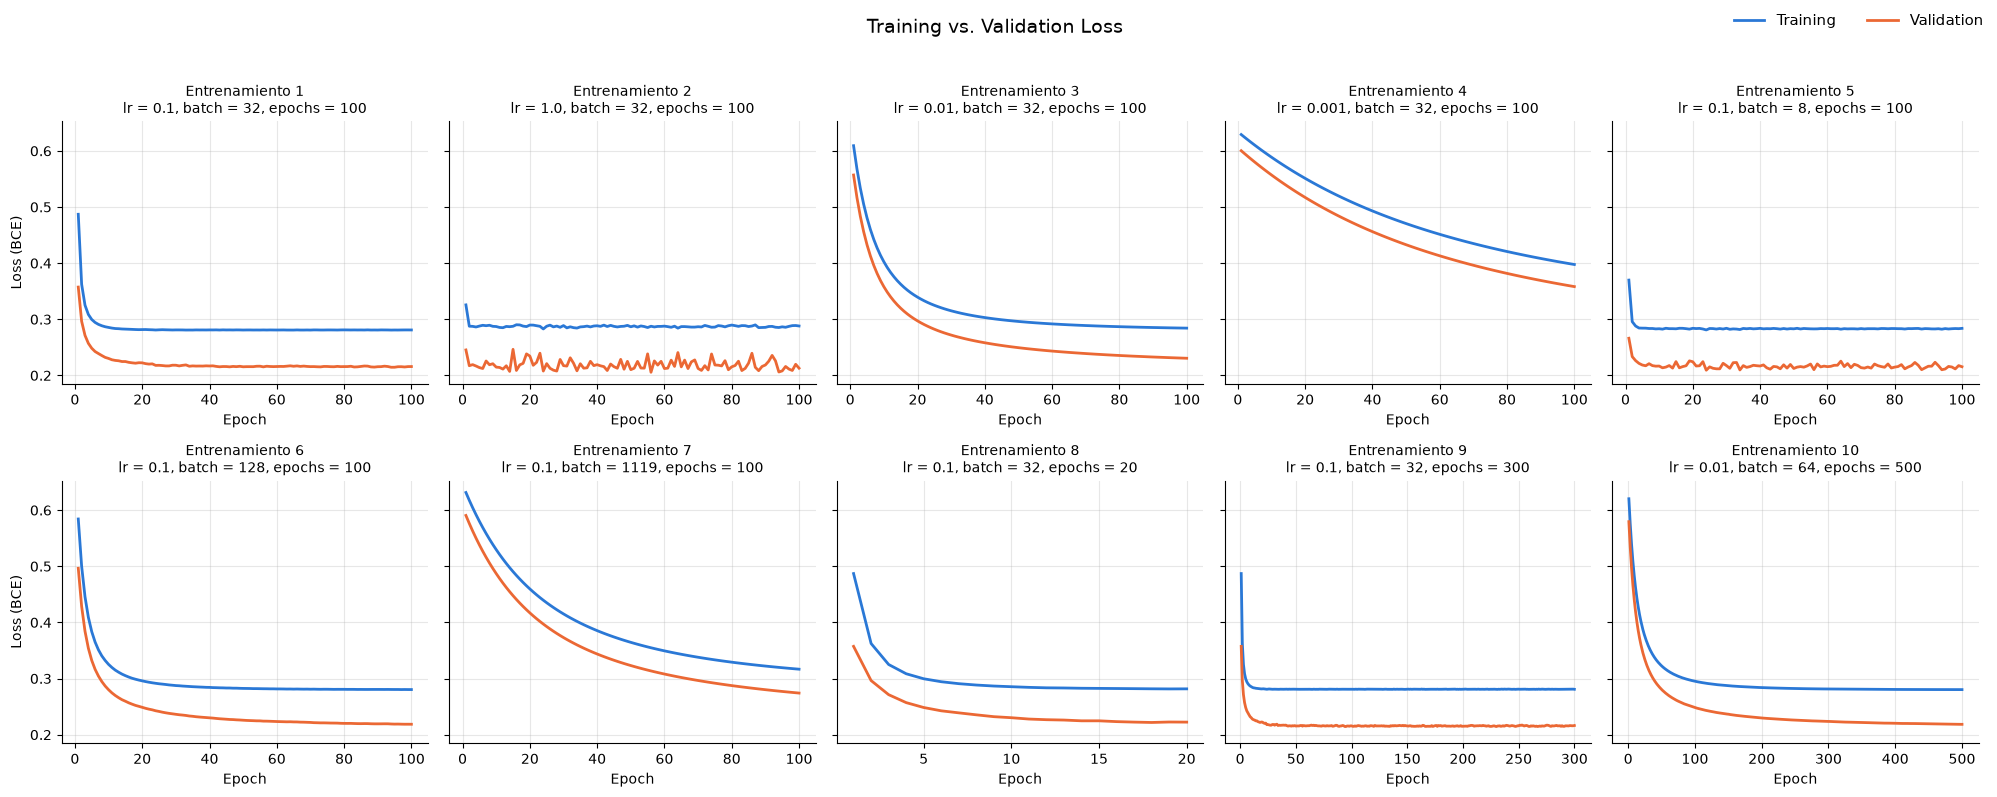

In [31]:
TRAIN_COLOR, VAL_COLOR = "#2a78d6", "#eb6834"

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for ax, run_id in zip(axes.flat, sorted(results)):
    r = results[run_id]
    epochs_range = range(1, r["epochs"] + 1)
    ax.plot(epochs_range, r["history"]["train_loss"], color=TRAIN_COLOR, lw=2, label="Training")
    ax.plot(epochs_range, r["history"]["val_loss"], color=VAL_COLOR, lw=2, label="Validation")
    ax.set_title(f"Entrenamiento {run_id}\nlr = {r['lr']}, batch = {r['batch_size']}, epochs = {r['epochs']}",
                 fontsize=10)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("Loss (BCE)")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, frameon=False, fontsize=11)
fig.suptitle("Training vs. Validation Loss", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig("resultados/curvas_perdida.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis de overfitting

Hay overfitting cuando la pérdida de entrenamiento sigue bajando mientras la de validación deja de bajar y empieza a subir, o cuando la pérdida de validación queda por encima de la de entrenamiento. Para comprobarlo, se realiza lo siguiente:

In [32]:
def dataset_loss(model, X_t, y_t):
    # Pérdida BCE del modelo final sobre un set completo
    model.eval()
    with torch.no_grad():
        return nn.functional.binary_cross_entropy(model(X_t), y_t).item()


rows = []
for run_id in sorted(results):
    r = results[run_id]
    val_hist = np.array(r["history"]["val_loss"])
    train_loss = dataset_loss(r["model"], X_train_t, y_train_t)
    val_loss = dataset_loss(r["model"], X_val_t, y_val_t)
    rows.append({
        "id": run_id,
        "train loss": train_loss,
        "val loss": val_loss,
        "val - train": val_loss - train_loss,
        "mín. val loss": val_hist.min(),
        "época del mín.": val_hist.argmin() + 1,
        "aumento desde el mín.": val_loss - val_hist.min(),
    })

overfitting = pd.DataFrame(rows).set_index("id")
overfitting.round(4)

,train loss,val loss,val - train,mín. val loss,época del mín.,aumento desde el mín.
id,,,,,,
1,0.2801,0.2158,-0.0643,0.2145,94,0.0012
2,0.2815,0.2129,-0.0686,0.2056,56,0.0073
3,0.2841,0.2306,-0.0535,0.2306,100,0.0000
4,0.3971,0.3582,-0.0388,0.3582,100,0.0000
5,0.2803,0.2154,-0.0648,0.2093,24,0.0062
6,0.2803,0.2186,-0.0617,0.2186,100,0.0000
7,0.3162,0.2742,-0.0420,0.2742,100,0.0000
8,0.2807,0.2224,-0.0583,0.2218,18,0.0006
9,0.2801,0.2163,-0.0638,0.2144,230,0.0019


Ninguno de los 10 entrenamientos presenta overfitting. En todos, la pérdida de validación termina por debajo de la de entrenamiento (entre 0.04 y 0.07 menos), lo cual no es un error: el set de validación es pequeño (240 vinos) y resultó un poco más fácil de clasificar. Además, la pérdida de validación nunca empieza a subir mientras la de entrenamiento baja, que es la señal típica de overfitting. El mayor aumento respecto a su mínimo fue de apenas 0.007, en el entrenamiento 2, y se debe a que con lr = 1.0 los pasos son tan grandes que la pérdida oscila; algo parecido, pero más leve, pasa con el batch de 8 del entrenamiento 5.

Incluso entrenando 300 y 500 épocas (entrenamientos 9 y 10) las curvas se quedan planas una vez que convergen. Tiene sentido, porque la regresión logística solo tiene 7 parámetros y no tiene capacidad para memorizar los datos. El problema que sí aparece es el contrario, underfitting, en los entrenamientos 4 (lr = 0.001) y 7 (batch completo, una sola actualización por época): en ambos la pérdida sigue bajando al terminar, es decir, no les alcanzaron las épocas para converger. El entrenamiento 3 también converge lento, pero llega casi al mismo nivel que los demás.

### Métricas y cuadro comparativo de los 10 entrenamientos

Métricas sobre el set de validación, con umbral de decisión 0.5. El AUC se calcula con las probabilidades, por lo que no depende del umbral.

In [33]:
def evaluate(model, X_t, y_true, threshold=0.5):
    model.eval()
    with torch.no_grad():
        probs = model(X_t).cpu().numpy().ravel()
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "auc": roc_auc_score(y_true, probs),
    }

comparison = pd.DataFrame([
    {"id": r["id"], "lr": r["lr"], "batch_size": r["batch_size"], "epochs": r["epochs"],
     **evaluate(r["model"], X_val_t, y_val)}
    for r in (results[i] for i in sorted(results))
]).set_index("id")

comparison.to_csv("resultados/cuadro_comparativo.csv")
comparison.round(4)

,lr,batch_size,epochs,accuracy,precision,recall,f1,auc
id,,,,,,,,
1,0.100,32,100,0.9000,0.8000,0.3636,0.5000,0.9450
2,1.000,32,100,0.9042,0.8571,0.3636,0.5106,0.9504
3,0.010,32,100,0.8958,0.7857,0.3333,0.4681,0.9417
4,0.001,32,100,0.9042,0.8125,0.3939,0.5306,0.9179
5,0.100,8,100,0.9042,0.8571,0.3636,0.5106,0.9463
6,0.100,128,100,0.9000,0.8000,0.3636,0.5000,0.9447
7,0.100,1119,100,0.8958,0.8333,0.3030,0.4444,0.9378
8,0.100,32,20,0.9042,0.8571,0.3636,0.5106,0.9435
9,0.100,32,300,0.9042,0.8571,0.3636,0.5106,0.9448


**Cuadro comparativo (set de validación).** 

| # | Learning rate | Batch size | Epochs | Accuracy | Precision | Recall | F1-score | AUC |
|---|---|---|---|---|---|---|---|---|
| 1 | 0.1 | 32 | 100 | 0.9000 | 0.8000 | 0.3636 | 0.5000 | 0.9450 |
| 2 | 1.0 | 32 | 100 | **0.9042** | **0.8571** | 0.3636 | 0.5106 | **0.9504** |
| 3 | 0.01 | 32 | 100 | 0.8958 | 0.7857 | 0.3333 | 0.4681 | 0.9417 |
| 4 | 0.001 | 32 | 100 | **0.9042** | 0.8125 | **0.3939** | **0.5306** | 0.9179 |
| 5 | 0.1 | 8 | 100 | **0.9042** | **0.8571** | 0.3636 | 0.5106 | 0.9463 |
| 6 | 0.1 | 128 | 100 | 0.9000 | 0.8000 | 0.3636 | 0.5000 | 0.9447 |
| 7 | 0.1 | 1119 | 100 | 0.8958 | 0.8333 | 0.3030 | 0.4444 | 0.9378 |
| 8 | 0.1 | 32 | 20 | **0.9042** | **0.8571** | 0.3636 | 0.5106 | 0.9435 |
| 9 | 0.1 | 32 | 300 | **0.9042** | **0.8571** | 0.3636 | 0.5106 | 0.9448 |
| 10 | 0.01 | 64 | 500 | 0.9000 | 0.8000 | 0.3636 | 0.5000 | 0.9445 |

Los entrenamientos que llegan a converger (1, 2, 5, 6, 8, 9 y 10) obtienen prácticamente las mismas métricas, con un AUC entre 0.94 y 0.95 y un F1 cercano a 0.50. Esto muestra que, una vez que el modelo converge, los hiperparámetros solo cambian qué tan rápido llega a la solución, no la solución a la que llega. Las diferencias aparecen en los que no terminaron de converger: el entrenamiento 4 (lr = 0.001) baja a un AUC de 0.918, el 7 (batch completo) a 0.938, y el 3 (lr = 0.01) queda un poco por debajo del resto en F1. El entrenamiento 4 tiene el F1 más alto (0.531), pero no por ser mejor modelo: con un set de validación pequeño, detectar un solo vino bueno más ya sube el F1, y su AUC deja claro que separa peor las clases.

El accuracy ronda 0.90 en todos y no sirve para compararlos, ya que un modelo que siempre prediga MALO obtendría cerca de 0.86. Lo que sí se repite en todos los modelos es una precision alta (0.79 a 0.86) y un recall bajo (alrededor de 0.36): cuando el modelo dice que un vino es BUENO casi siempre acierta, pero solo encuentra cerca de un tercio de los vinos buenos. Esto es consecuencia del desbalance de clases y del umbral de 0.5, ya que el modelo rara vez da probabilidades altas para la clase minoritaria.

## Análisis de resultados

### Selección del mejor modelo

*TODO: criterio de selección (p. ej. mayor F1 o AUC en validación).*

In [ ]:
# TODO: seleccionar el mejor entrenamiento
best = None

### Comparación entrenamiento vs. prueba

In [ ]:
# TODO: comparar métricas del mejor modelo en train vs test
# pd.DataFrame({"train": evaluate(best["model"], X_train_t, y_train),
#               "test": evaluate(best["model"], X_test_t, y_test)})

### Matriz de confusión (set de prueba)

In [ ]:
# TODO: matriz de confusión del mejor modelo sobre el set de prueba
# ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=["MALO", "BUENO"]).plot()

### Métricas finales en el set de prueba

In [ ]:
# TODO: métricas finales del mejor modelo sobre el set de prueba

### Discusión y conclusiones

*TODO*